In [1]:
##This work represents the capstone project for the Google Advanced Data Analytics Certificate. An analysis of HR data will be performed to try and predict whether or not an employee
##will leave the company(churn). An analysis of the most relevant factors will be conducted and will guide reccomendations made to help reduce employee churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sms
import os
import pickle

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:
df = pd.read_csv('HR_comma_sep.csv')

In [4]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
df.shape

(14999, 10)

In [7]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [8]:
df_num_projects = df.groupby('number_project').agg(Avg_monthly_hours=('average_montly_hours', 'mean'), Avg_evaluation=('last_evaluation', 'mean'),
                                 Avg_time_company=('time_spend_company', 'mean'), promoted_5_years=('promotion_last_5years', 'sum'),
                                 satisfaction_level=('satisfaction_level', 'mean'), tenure=('time_spend_company', 'mean'),
                                 churn=('left', 'mean')).reset_index()
df_num_projects

,number_project,Avg_monthly_hours,Avg_evaluation,Avg_time_company,promoted_5_years,satisfaction_level,tenure,churn
0,2,160.342546,0.568505,3.180486,37,0.478769,3.180486,0.656198
1,3,197.507522,0.716572,3.286560,95,0.687670,3.286560,0.017756
2,4,205.122108,0.740009,3.454983,117,0.695132,3.454983,0.093700
3,5,212.061572,0.762010,3.800072,50,0.678888,3.800072,0.221659
4,6,238.694208,0.786550,4.192504,20,0.273458,4.192504,0.557922
5,7,276.078125,0.859609,4.113281,0,0.118711,4.113281,1.000000


In [9]:
##Since we are trying to understand employee churn rate, the low hanging fruit of the dataset is to try and understand how employees working with less projects compare to employess
##working with more projects. The above pivot table is generated using the groupby command to list average_monthly_hours, average_evaluation_score, average time at the company,
##whether or not the employee was promoted in 5 years, and employee_satisfaction_level. The table shows a clear disctinction in the data, employees who contribute to 3-5 projects
##work hours much closer to the mean number of worked hours (201.05), have evaluation scores much closer to the mean (0.716), have the highest number of promotions within the passed 5
##years, and a greater satisfaction level than any other group. Employees who manage 6-7 projects (7 projects is the maximum managed), have the highest evaluation score and longest 
##time at the company, but have the least amount of promotions in the last 5 years and also report the lowest satisfaction level. When employees only manage 2 projects, their monthly
##hours and average evaluation scores drastically drop but the number of promotions and satisfaction is mid teir.

##An interesting insight is that all employees with 7 managed projects churned. This shows that as the number of projects an employee manages gets large, the chance of a churn approaches 
##100%. However, the next biggest churn rate comes from employees managing only 2 projects. This could definitley be a correlation between senior and junior workers churning based on
##the number of projects they have. 

In [10]:
df_churn_7_projects = df[df['number_project'] == 7]
df_churn_7_projects['left'].value_counts(normalize=True) ##verify that all employees managaging 7 projects had a 100% churn rate

left
1    1.0
Name: proportion, dtype: float64

In [11]:
df_time_spend_company = df.groupby('time_spend_company').agg(number_project=('number_project', 'mean'), satisfaction_level=('satisfaction_level', 'mean'), 
                                     monthly_hours=('average_montly_hours', 'mean'), promoted=('promotion_last_5years', 'sum'),
                                     churn=('left', 'mean')).reset_index()
df_time_spend_company

,time_spend_company,number_project,satisfaction_level,monthly_hours,promoted,churn
0,2,3.687423,0.697078,200.133169,54,0.016338
1,3,3.327798,0.626314,186.632935,134,0.246159
2,4,4.627689,0.467517,223.455221,35,0.348064
3,5,4.519348,0.610305,222.978955,17,0.565513
4,6,4.213092,0.603440,212.051532,17,0.291086
5,7,3.851064,0.635957,200.744681,36,0.000000
6,8,3.777778,0.665062,193.802469,10,0.000000
7,10,3.682243,0.655327,199.224299,16,0.000000


In [12]:
##looking at the time an employee spends at the company does not necessarily provide any extra insight into churn speficially. It does point out however, that most employees who were
##promoted in the last 5 years had only spent 3 years with the company. In addition, the chart does show that at least some employees at each level of tenure were promoted within the 
##last 5 years. However, out of 14,999 employess at the company, only 319 (2.12%) have recieved a promotion in the last 5 years. Another interesting observation is that employees who
##have worked for 4 years tend to manage the most number of projects and have the lowest satisfaction level, which a relativley low promotion rate, and the second highest churn rate.
##Finally, employees with the highest tenure(7-10), although they do not have the highest promotion rate, work some of the lowest average hours and have a 0% churn rate

In [13]:
df_work_accident = df.groupby('Work_accident').agg(count=('Work_accident', 'count'),time_spend_company=('time_spend_company', 'mean'), satisfaction_level=('satisfaction_level', 'mean'), 
                                churn=('left','sum')).reset_index()
df_work_accident['churn_rate'] = df_work_accident['churn'] / df_work_accident['count']
df_work_accident['Work_accident'] = df_work_accident['Work_accident'].replace({0:'No Accident', 1: 'Accident'})
df_work_accident

,Work_accident,count,time_spend_company,satisfaction_level,churn,churn_rate
0,No Accident,12830,3.496960,0.606833,3402,0.265160
1,Accident,2169,3.505763,0.648326,169,0.077916


In [14]:
##My initial impression is that work accidents don't necessarily have an effect on churn rate. Looking at the pivot table above, churn rate when there is no accident is almost 26%
##whereas churn rate for when there is an accident is only 7.7%. In addition, time spent at the company is near identical and average satisfaction level is actually slightly higher
##than employees without and accident

In [15]:
df_department = df.groupby('Department').agg(employee_count=('Department', 'count'), sasifaction=('satisfaction_level', 'mean'), tenure=('time_spend_company', 'mean'), hours=('average_montly_hours', 'mean'),
                             promotion=('promotion_last_5years', 'sum'), num_projects=('number_project', 'mean'), evaluation=('last_evaluation', 'mean'),
                             count_churn=('left', 'sum'), churn_rate=('left', 'mean')).reset_index()
df_department

,Department,employee_count,sasifaction,tenure,hours,promotion,num_projects,evaluation,count_churn,churn_rate
0,IT,1227,0.618142,3.468623,202.215974,3,3.816626,0.716830,273,0.222494
1,RandD,787,0.619822,3.367217,200.800508,27,3.853875,0.712122,121,0.153748
2,accounting,767,0.582151,3.522816,201.162973,14,3.825293,0.717718,204,0.265971
3,hr,739,0.598809,3.355886,198.684709,15,3.654939,0.708850,215,0.290934
4,management,630,0.621349,4.303175,201.249206,69,3.860317,0.724000,91,0.144444
5,marketing,858,0.618601,3.569930,199.385781,43,3.687646,0.715886,203,0.236597
6,product_mng,902,0.619634,3.475610,199.965632,0,3.807095,0.714756,198,0.219512
7,sales,4140,0.614447,3.534058,200.911353,100,3.776329,0.709717,1014,0.244928
8,support,2229,0.618300,3.393001,200.758188,20,3.803948,0.723109,555,0.248991
9,technical,2720,0.607897,3.411397,202.497426,28,3.877941,0.721099,697,0.256250


In [16]:
##A pivot table of the company departments shows that the largest churn count came from sales, followed by techical, and support. However, the two derparments experiencing the most
##relative churn are hr and accounting with a 29% churn rate and a 26.5% churn rate, respectively. These departments have the two lowest employee satisfaction scores at 0.598 and
##0.582 respectively. Accounting is also in the top 3 departments for average hours worked and average number of projects, with 201.16 and 3.825, respectivley. 

C:\Users\matth\AppData\Local\Temp\ipykernel_9268\2131253581.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  projects_plot = sns.barplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_9268\2131253581.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tenure_plot = sns.barplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_9268\2131253581.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  work_accident_plot = sns.barplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_9268\2131253581.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

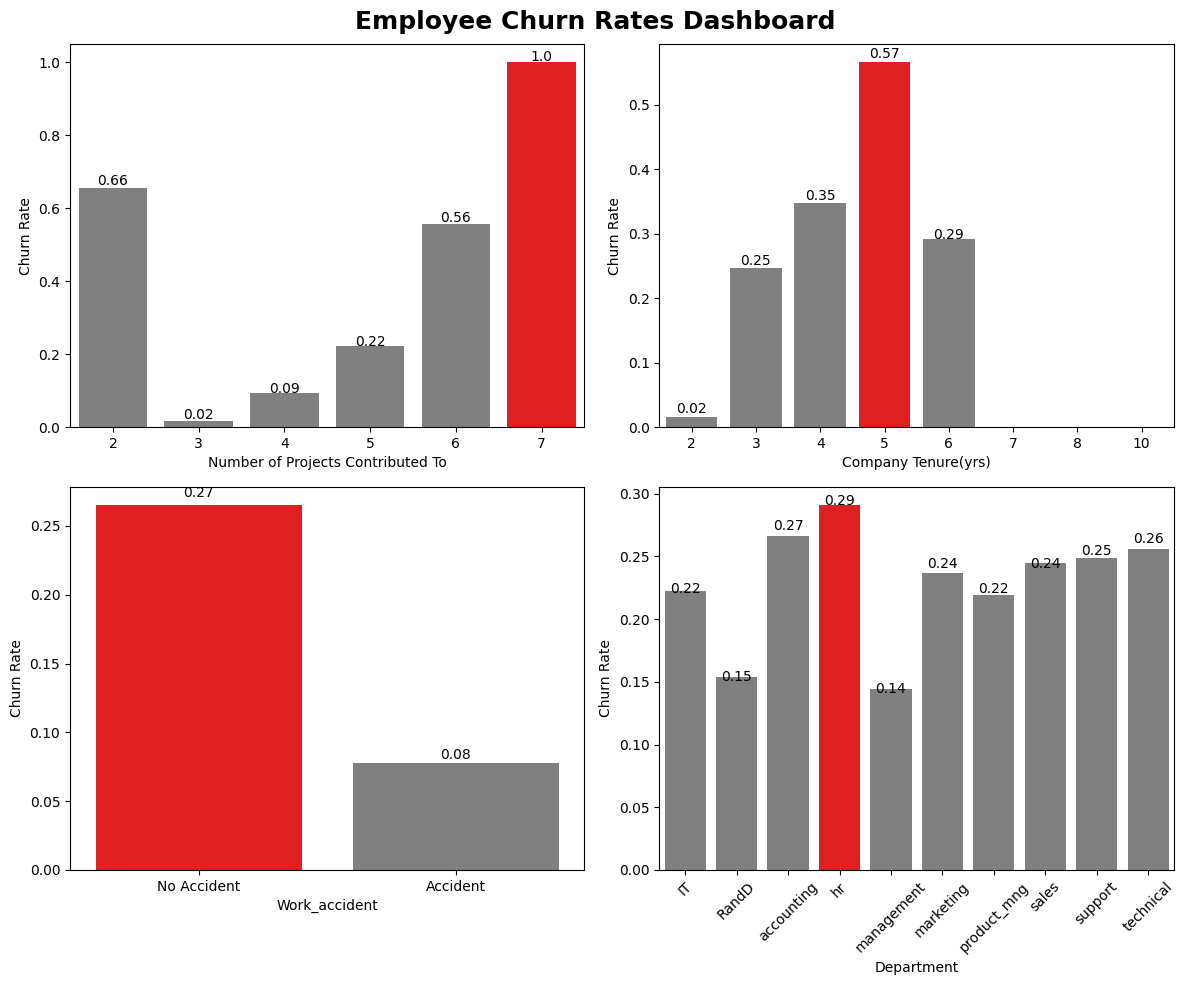

In [17]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
fig.suptitle('Employee Churn Rates Dashboard', fontsize='18', fontweight='bold')

values_projects = df_num_projects['churn']
values_time_spend_company = df_time_spend_company['churn']
values_work_accident = df_work_accident['churn_rate']
values_department = df_department['churn_rate']

cutoms_colors_projects = ['red' if x==max(values_projects) else 'grey' for x in values_projects]
cutoms_colors_time_spent_company = ['red' if x==max(values_time_spend_company) else 'grey' for x in values_time_spend_company]
cutoms_colors_work_accident = ['red' if x==max(values_work_accident) else 'grey' for x in values_work_accident]
cutoms_colors_department = ['red' if x==max(values_department) else 'grey' for x in values_department]

projects_plot = sns.barplot(
    x=df_num_projects['number_project'],
    y=df_num_projects['churn'],
    palette=cutoms_colors_projects,
    ax=axes[0,0]
)

tenure_plot = sns.barplot(
    x=df_time_spend_company['time_spend_company'],
    y=df_time_spend_company['churn'],
    palette=cutoms_colors_time_spent_company,
    ax=axes[0,1]
)

work_accident_plot = sns.barplot(
    x=df_work_accident['Work_accident'],
    y=df_work_accident['churn_rate'],
    palette=cutoms_colors_work_accident,
    ax=axes[1,0]
)

department_plot = sns.barplot(
    x=df_department['Department'],
    y=df_department['churn_rate'],
    palette=cutoms_colors_department,
    ax=axes[1,1]
)

axes[1,1].tick_params(axis = 'x', rotation=45)

axes[0,0].set_xlabel('Number of Projects Contributed To')
axes[0,0].set_ylabel('Churn Rate')
axes[0,1].set_xlabel('Company Tenure(yrs)')
axes[0,1].set_ylabel('Churn Rate')
axes[1,0].set_ylabel('Churn Rate')
axes[1,1].set_ylabel('Churn Rate')

list_plots = [projects_plot, tenure_plot, work_accident_plot, department_plot]
for i in list_plots:
    for b in i.patches:
        if b.get_height() != 0:
            i.annotate(b.get_height().round(2), 
                (b.get_x().round(2) + b.get_width().round(2)/ 2, b.get_height().round(2)), 
                ha = 'center', va = 'bottom', 
                xytext = (0, -1.5), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [18]:
##The above dashboard gives a visual overview of churn rates generated in the tables above at Salifort Motors. Based on the graphs (and tables), it is quite clear that the number
##of projects that an employee contributes to will greatly increase their individual chance to churn as well as the time spent at the company. Although not as prominant, the department
##that an employee works in can also contribute to the churn rate. Although most deparments seem about even in the 0.22-0.25 range, hr and accounting have larger churn rates at 
##0.29 and 0.27 respectively

In [19]:
##--Starting cleaning and EDA in dataset--##

In [20]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


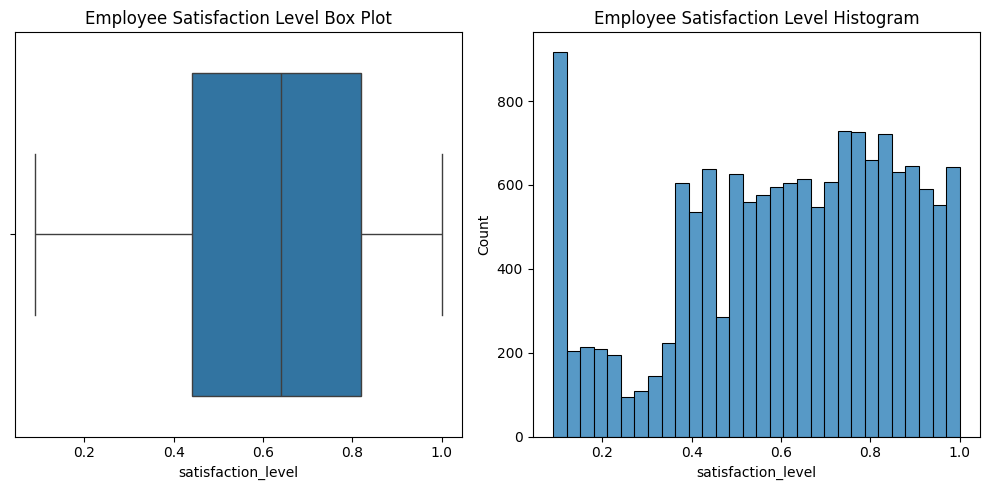

In [21]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

satisfaction = sns.boxplot(
    x = df['satisfaction_level'],
    ax = axes[0]
)

satisfaction_hist = sns.histplot(
    x=df['satisfaction_level'],
    ax = axes[1]
)

axes[0].set_title('Employee Satisfaction Level Box Plot')
axes[1].set_title('Employee Satisfaction Level Histogram')

plt.tight_layout()
plt.show()

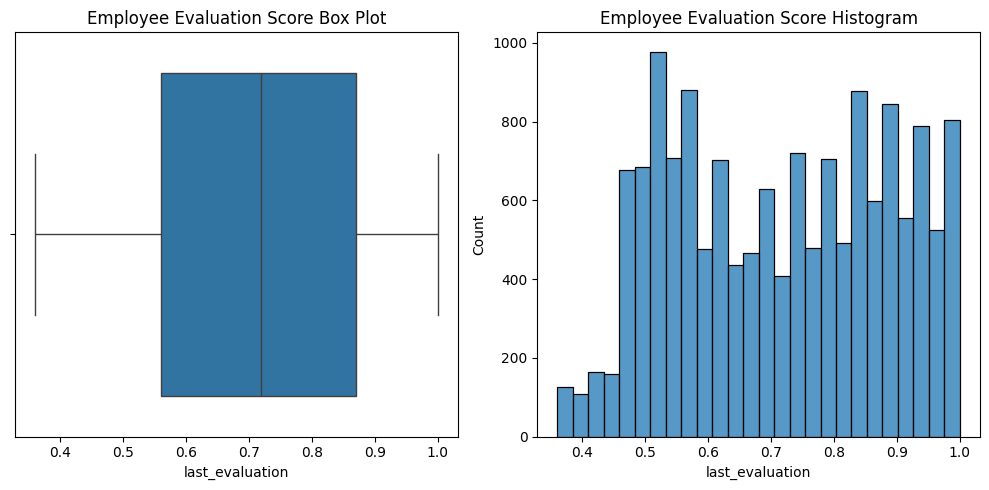

In [22]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

evaluation= sns.boxplot(
    x = df['last_evaluation'],
    ax = axes[0]
)

evaluation_hist = sns.histplot(
    x=df['last_evaluation'],
    ax = axes[1]
)

axes[0].set_title('Employee Evaluation Score Box Plot')
axes[1].set_title('Employee Evaluation Score Histogram')

plt.tight_layout()
plt.show()

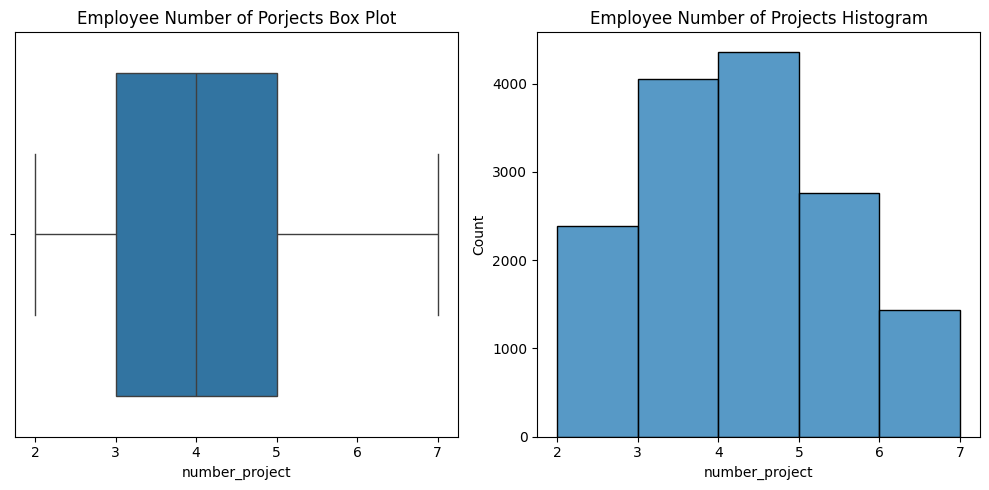

In [23]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

num_projects = sns.boxplot(
    x = df['number_project'],
    ax = axes[0]
)

num_projects_hist = sns.histplot(
    x=df['number_project'],
    bins=5,
    ax = axes[1]
)

axes[0].set_title('Employee Number of Porjects Box Plot')
axes[1].set_title('Employee Number of Projects Histogram')

plt.tight_layout()
plt.show()

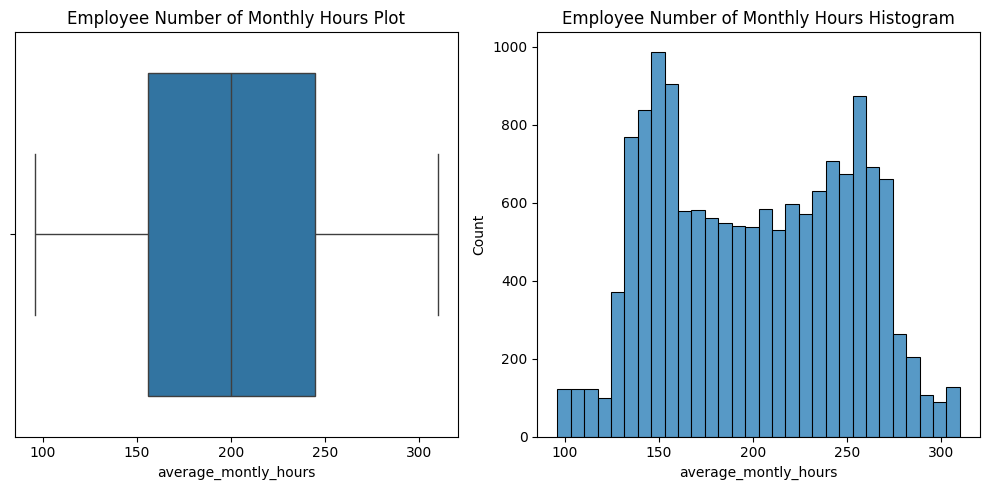

In [24]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

monthly_hours = sns.boxplot(
    x = df['average_montly_hours'],
    showfliers = True,
    ax = axes[0]
)

monthly_hours_hist = sns.histplot(
    x=df['average_montly_hours'],
    ax = axes[1]
)

axes[0].set_title('Employee Number of Monthly Hours Plot')
axes[1].set_title('Employee Number of Monthly Hours Histogram')

plt.tight_layout()
plt.show()

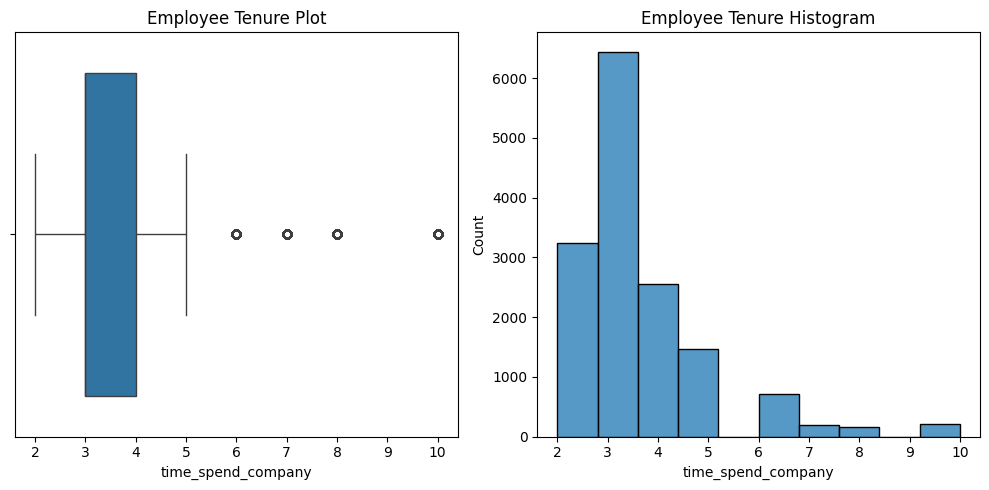

In [25]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

tenure = sns.boxplot(
    x = df['time_spend_company'],
    showfliers = True,
    ax = axes[0]
)

tenure_hist = sns.histplot(
    x=df['time_spend_company'],
    bins=10,
    ax = axes[1]
)

axes[0].set_title('Employee Tenure Plot')
axes[1].set_title('Employee Tenure Histogram')

plt.tight_layout()
plt.show()

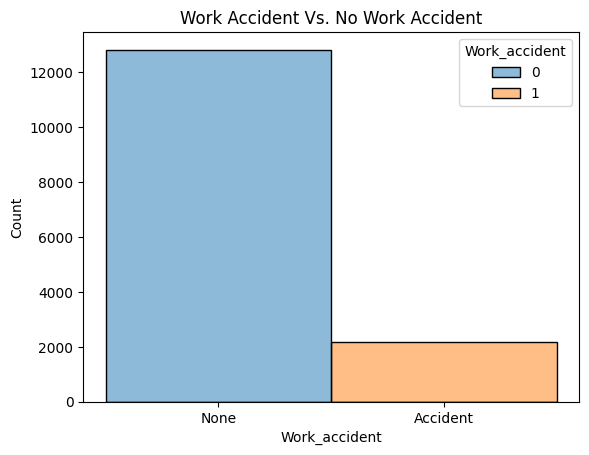

In [26]:
sns.histplot(
    x=df['Work_accident'].replace({0:'None', 1:'Accident'}),
    hue=df['Work_accident']
)

plt.title('Work Accident Vs. No Work Accident')
plt.show()

In [27]:
df['promotion_last_5years'].value_counts()

promotion_last_5years
0    14680
1      319
Name: count, dtype: int64

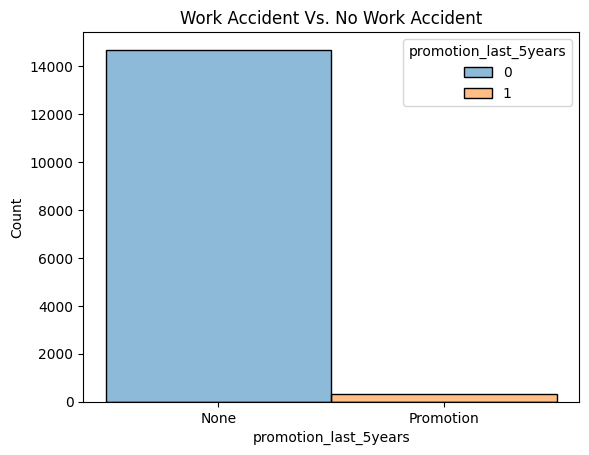

In [28]:
sns.histplot(
    x=df['promotion_last_5years'].replace({0:'None', 1:'Promotion'}),
    hue=df['promotion_last_5years']
)

plt.title('Work Accident Vs. No Work Accident')
plt.show()

In [29]:
##based on the charts shown above, none of the categories seem to have extreme outliers that need to be dealt with. Some categories have 'outliers' but seem acceptable within the context
##of the dataset. For example, tenure at the company shows outliers in between 5-10 years, while the median is closer to 3. Althought this is mathematically true, it would not be uncommon
##for an employee to be spending 5-10 years at a company. 

In [30]:
df.isna().replace({'False': 0, 'True':1}).sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [31]:
df['Department'].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [32]:
df_dep_salary_encoded = pd.get_dummies(df, columns=['Department','salary'], drop_first=True).replace({False:0, True:1})
df_dep_salary_encoded_trees = pd.get_dummies(df, columns=['Department', 'salary']).replace({False:0, True:1})

C:\Users\matth\AppData\Local\Temp\ipykernel_9268\2954329563.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dep_salary_encoded = pd.get_dummies(df, columns=['Department','salary'], drop_first=True).replace({False:0, True:1})
C:\Users\matth\AppData\Local\Temp\ipykernel_9268\2954329563.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dep_salary_encoded_trees = pd.get_dummies(df, columns=['Department', 'salary']).replace({False:0, True:1})


In [33]:
df['left'].value_counts(normalize=True)

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

In [34]:
##Since there is roughly a 75/25 split for churned vs non churned employees, not upsampling will be used. However, stratify will be used later in the notebook to preserve the ratio
##in training, test, and validation data sets.

In [35]:
corr = df_dep_salary_encoded.select_dtypes(include='number').corr()
corr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605,0.006615,-0.028649,-0.012841,0.007172,0.005715,0.006919,0.004007,0.009185,-0.009345,-0.047415,0.031367
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684,-0.005471,0.002193,-0.009645,0.009662,-0.000311,-0.001989,-0.023031,0.017104,0.013742,0.005221,0.006191
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064,0.009703,0.004189,-0.027356,0.009728,-0.023064,0.000829,-0.013388,0.000303,0.028596,-0.002504,0.007377
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544,-0.001177,0.000524,-0.010783,0.000834,-0.008210,-0.005494,-0.001718,-0.002444,0.013638,-0.001050,0.005007
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433,-0.021116,0.003909,-0.022194,0.115436,0.012096,-0.003919,0.015150,-0.030111,-0.027991,-0.040110,0.018299
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245,0.017167,-0.012836,-0.015649,0.011242,0.011367,0.001246,-0.004955,0.012079,-0.006070,-0.006813,0.001856
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788,-0.046596,0.015201,0.028249,-0.046035,-0.000859,-0.011029,0.009923,0.010700,0.020076,0.134722,-0.068833
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000,0.021268,-0.004852,-0.001531,0.128087,0.049253,-0.037288,0.012353,-0.035605,-0.035799,-0.082832,0.040985
Department_RandD,0.006615,-0.005471,0.009703,-0.001177,-0.021116,0.017167,-0.046596,0.021268,1.000000,-0.054629,-0.053570,-0.049274,-0.057965,-0.059525,-0.145300,-0.098315,-0.110755,-0.011887,0.020402
Department_accounting,-0.028649,0.002193,0.004189,0.000524,0.003909,-0.012836,0.015201,-0.004852,-0.054629,1.000000,-0.052848,-0.048610,-0.057183,-0.058723,-0.143341,-0.096989,-0.109262,-0.009759,0.003285


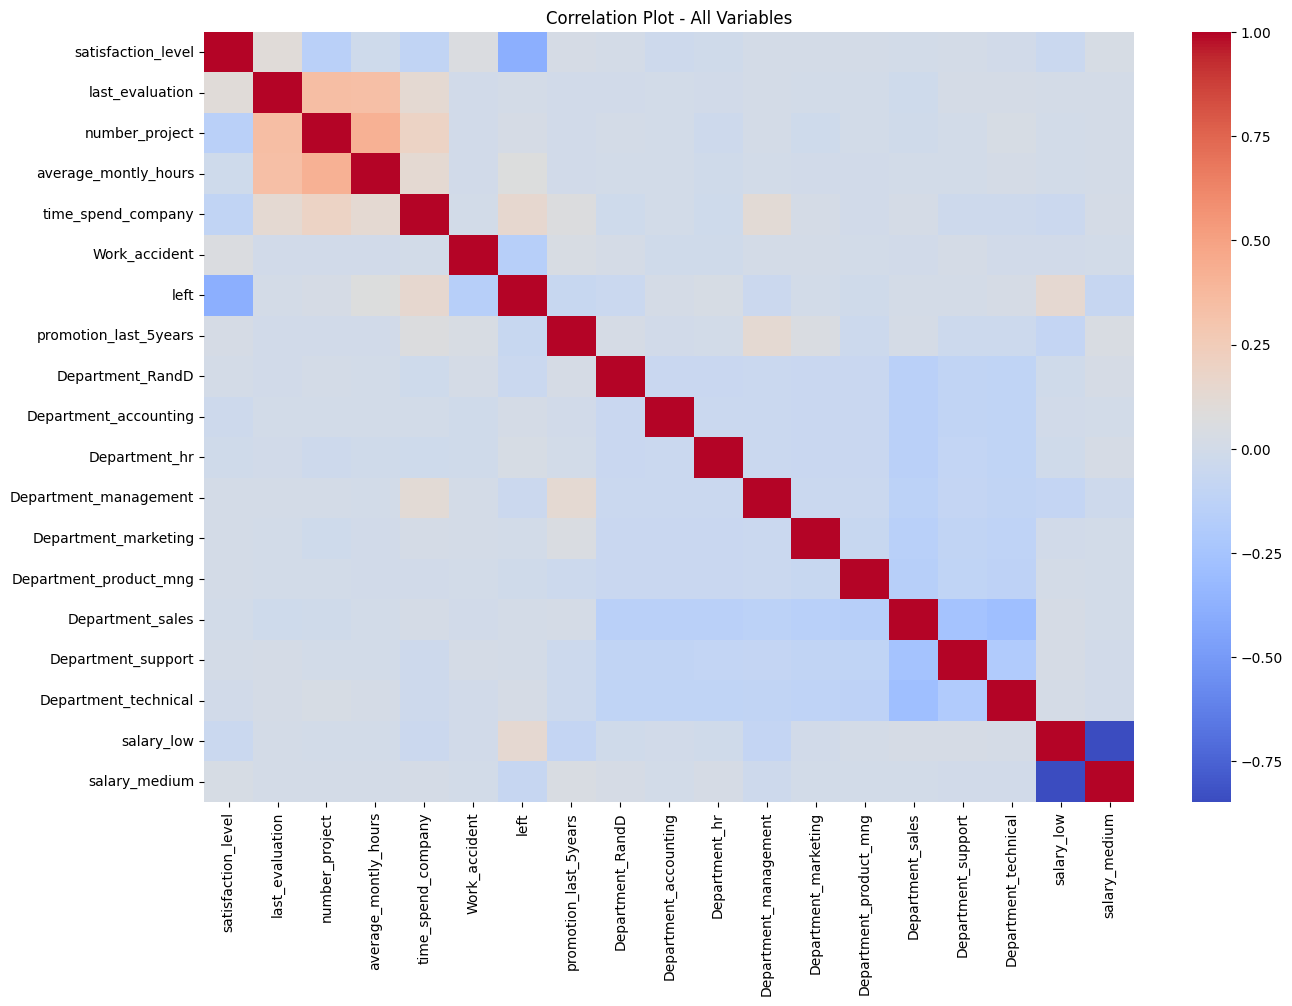

In [36]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    #annot=True
)

plt.title('Correlation Plot - All Variables')
plt.show()

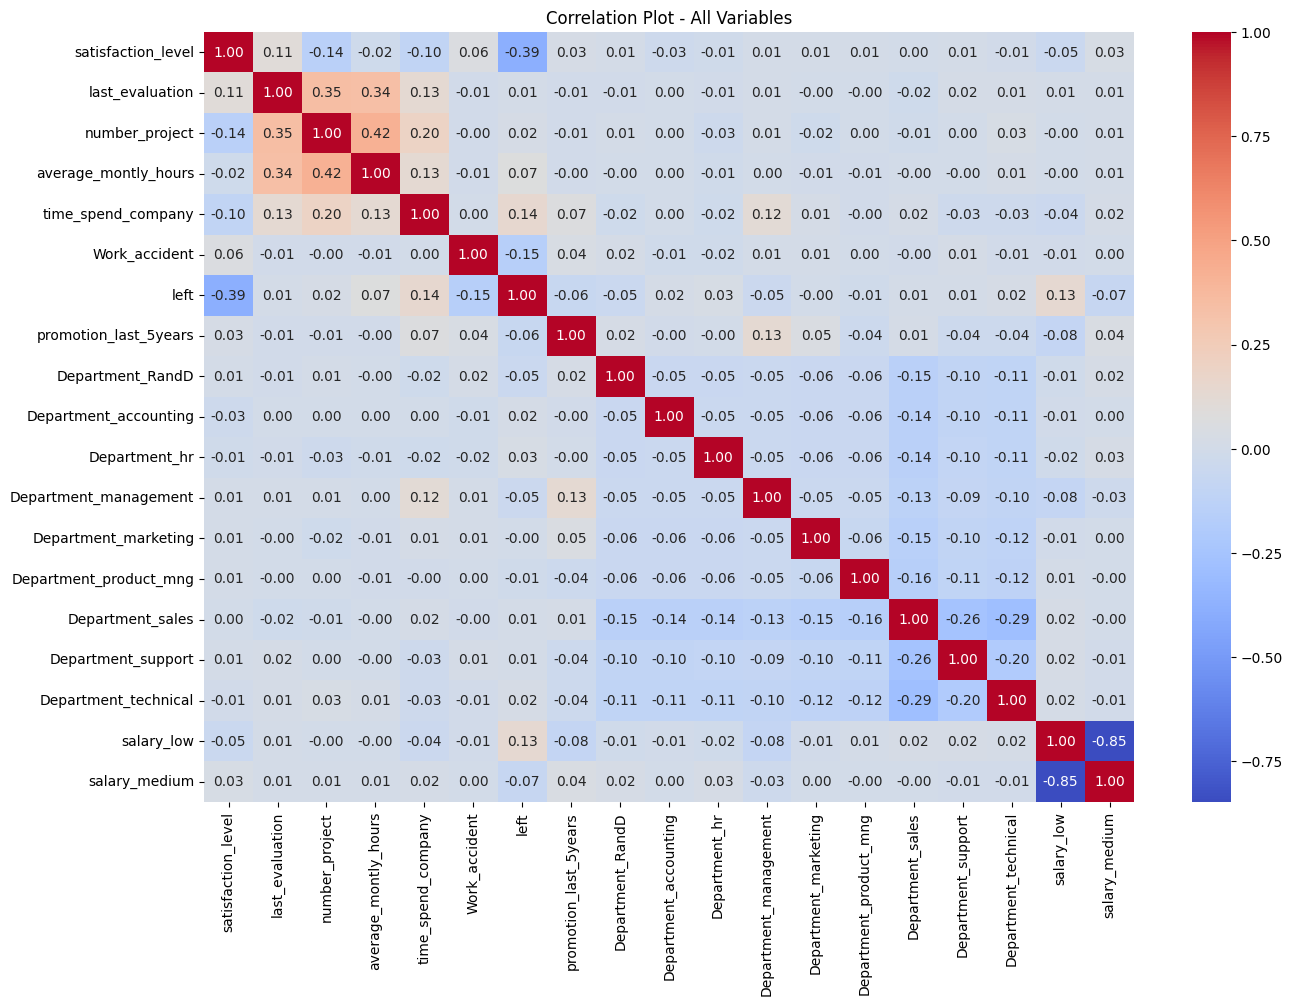

In [37]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    fmt=('.2f'),
    cmap='coolwarm',
    annot=True
)

plt.title('Correlation Plot - All Variables')
plt.show()

In [38]:
##The above heatmaps lay out the correlation in between variables in the dataframe. Only one pair of elements has a dangerously high correlation and it is two of the dummy encoded
##salary variables. Since those variables were forced to be correlated (if an employee has low salary, they cant have high salary or medium salary), and one dummy column was already
##dropped, these variables need to be maintained despite the no multicollinearity assumptions of some of the predictive models. 

In [39]:
df=df.drop_duplicates()

In [40]:
df_dep_salary_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [41]:
df_dep_salary_encoded['burn_out'] = (df_dep_salary_encoded['number_project'] > 6).astype(int)
##after running initial regression, this column is added to put more weight through the number of projects worked column. From the EDA dashboard above, employees with 7 or more projects
##are virtually guarenteed to churn. Adding this column should help relfect that.

In [42]:
df_dep_salary_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium,burn_out
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0


In [43]:
continuous_columns = ['number_project', 'average_montly_hours', 'time_spend_company']

In [44]:
X = df_dep_salary_encoded.drop(columns=['left'])
y = df_dep_salary_encoded['left']

In [45]:
X_build, X_val, y_build, y_val = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_build, y_build, test_size=0.25, stratify=y_build, random_state=42)

In [46]:
##Training, testing, and validation datasets have been created. Different models will be run on the validation set to determine which one will best predict the employee churn rate.
##I will start off with a basic logistic model, work through several iterations of a Naive Bayes model, a random forest classifier, and finally an xgboost classifier. Whichever runs
##with the best statistics on the val set will be run on the final test set to draw any final inference about what is causing employee churn.

In [47]:
scaler = StandardScaler()

In [48]:
X_train[continuous_columns] = scaler.fit_transform(X_train[continuous_columns])
X_val[continuous_columns] = scaler.transform(X_val[continuous_columns])
X_test[continuous_columns] = scaler.transform(X_test[continuous_columns])

In [49]:
log_reg = LogisticRegression(random_state=42)

In [50]:
cv_param_grid_lr = {
    'penalty' : ['l1', 'l2'],
    'C' : [0.01, 0.1, 1, 10, 100],
    'class_weight' : [None, 'balanced']
}

In [51]:
scoring_lr = ['accuracy', 'precision', 'recall', 'f1']

In [52]:
log_reg_cv = GridSearchCV(log_reg, cv_param_grid_lr, cv=5, scoring=scoring_lr, refit='f1')

In [53]:
log_reg_cv.fit(X_train, y_train)

c:\Users\matth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\matth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\matth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [54]:
log_reg_cv.best_params_

{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2'}

In [55]:
log_reg_cv_best = log_reg_cv.best_estimator_

In [56]:
y_log_reg_val_pred = log_reg_cv_best.predict(X_val)

In [57]:
print('Accuracy Score: ', round(accuracy_score(y_val, y_log_reg_val_pred), 2))
print('Recall Score: ', round(recall_score(y_val, y_log_reg_val_pred), 2))
print('precision Score: ', round(precision_score(y_val, y_log_reg_val_pred), 2))

Accuracy Score:  0.78
Recall Score:  0.85
precision Score:  0.52


In [58]:
##Model Has high accuracy and recall, but really poor precision. Essentially the model is way to anxious, even though for 8/10 people that it predicts will leave, 8 do leave,
##the model has about a 50/50 shot of predicting an employee to leave regardless. This is problematic so more advanced models will be tried to try and access better results.

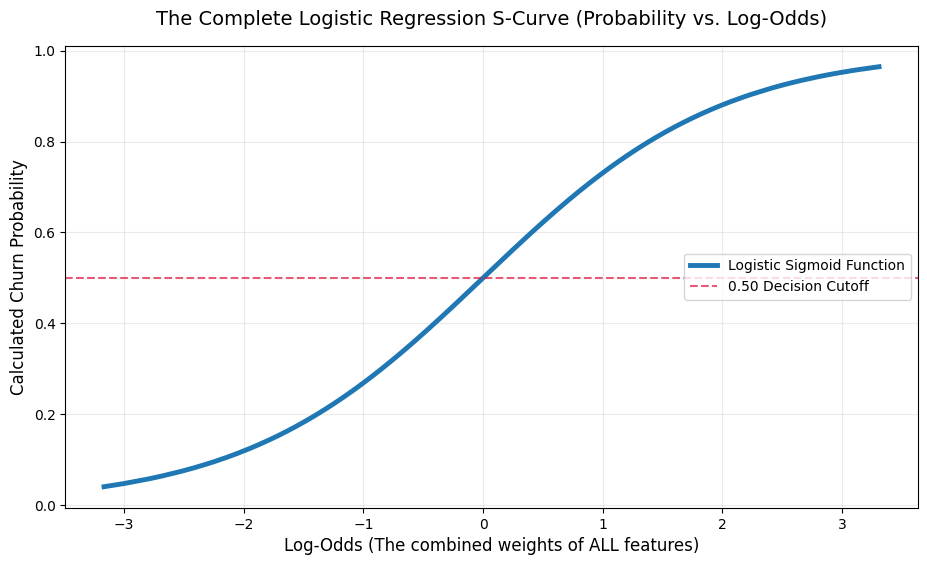

In [59]:
y_probs = log_reg_cv_best.predict_proba(X_val)[:, 1]

y_probs_clipped = np.clip(y_probs, 1e-5, 1 - 1e-5)
log_odds = np.log(y_probs_clipped / (1 - y_probs_clipped))

sort_indices = np.argsort(log_odds)
log_odds_sorted = log_odds[sort_indices]
y_probs_sorted = y_probs[sort_indices]

plt.figure(figsize=(11, 6))

plt.plot(log_odds_sorted, y_probs_sorted, color='#1f77b4', linewidth=3.5, label='Logistic Sigmoid Function')

plt.axhline(0.5, color='crimson', linestyle='--', alpha=0.7, label='0.50 Decision Cutoff')

plt.title("The Complete Logistic Regression S-Curve (Probability vs. Log-Odds)", fontsize=14, pad=15)
plt.xlabel("Log-Odds (The combined weights of ALL features)", fontsize=12)
plt.ylabel("Calculated Churn Probability", fontsize=12)
plt.legend(loc='center right', fontsize=10)
plt.grid(True, alpha=0.25)

plt.show()

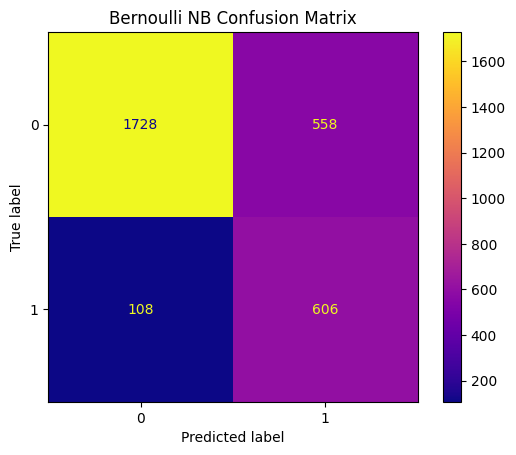

In [60]:
cm = metrics.confusion_matrix(y_val, y_log_reg_val_pred, labels=log_reg_cv_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_cv_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Bernoulli NB Confusion Matrix')
plt.show()

In [61]:
##The above S curve validates the logistic regression model is most likely constructed appropriately after a few tweaks. Finally the confusion matrix above tells the whole story: Employees
##predicted to stay, who stayed, are the highest count at 1728. The axiety disucussed above becomes abunantly clear in the false positive block, a 558 count. This is where the model is
##basically just guessing who is quitting, and it is happening quite frequently. On the flip side, the false negatives, is quite low because we have such a high recall, and is relfected
##in the 108 count. The model was able to get 606 true positive results and correctly predict 606 employees churning.

In [62]:
##We can now try various versions of of the Naive Bayes model to see if we can predict employee churn. There is a hitch, this data has been split into two categories, continuous and
##binary encoded data. Bernoulli NB can handle the encoded data only, while Gauss NB can handle the continuous data only. In addition, Gauss NB assume a normal distributino of the data,
##which we know from EDA is untrue, but due to the way the algorithm works, it can still make a decent prediction so it's worth trying. The strategy is to split the data into encoded
##and continuous variables, and then create models for only those. We can then isolate some variables and determine if they indvidually have a large impact on the churn

In [63]:
bern_nb = BernoulliNB()

In [64]:
cols_to_drop_multi_nb = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']
X_train_mnb = X_train.drop(columns=cols_to_drop_multi_nb)
X_val_mnb = X_val.drop(columns=cols_to_drop_multi_nb)

In [65]:
bern_nb.fit(X_train_mnb, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [66]:
y_pred_mnb_val = bern_nb.predict(X_val_mnb)

In [67]:
print('Accuracy Score: ', round(accuracy_score(y_val, y_pred_mnb_val), 2))
print('Recall Score: ', round(recall_score(y_val, y_pred_mnb_val), 2))
print('precision Score: ', round(precision_score(y_val, y_pred_mnb_val), 2))

Accuracy Score:  0.78
Recall Score:  0.08
precision Score:  1.0


In [68]:
##After running the prediction just using Bernoulli NB with enocded variables, we get a model that predicts on a very cautios level. This is shown in the precision and recall score:
##The precision score shows that when the model finally wants to flag someone, they are going to churn. The problem is, with a reall of 0.08, the model is getting 92% false negative 
##values. E.g. it does not want to predict whether people leave or not. --> This model is not usable

In [69]:
gauss_nb = GaussianNB()

In [70]:
cols_to_drop_gaus_nb = ['promotion_last_5years', 'Department_RandD', 'Department_accounting', 'Department_hr', 'Department_management', 
                        'Department_marketing',	'Department_product_mng', 'Department_sales', 'Department_support',	'Department_technical', 'salary_low', 'salary_medium', 'burn_out']
X_train_gnb = X_train.drop(columns=cols_to_drop_gaus_nb)
X_val_gnb = X_val.drop(columns=cols_to_drop_gaus_nb)

In [71]:
gauss_nb.fit(X_train_gnb, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [72]:
y_pred_gnb_val = gauss_nb.predict(X_val_gnb)

In [73]:
print('Accuracy Score: ', round(accuracy_score(y_val, y_pred_gnb_val), 2))
print('Recall Score: ', round(recall_score(y_val, y_pred_gnb_val), 2))
print('precision Score: ', round(precision_score(y_val, y_pred_gnb_val), 2))

Accuracy Score:  0.85
Recall Score:  0.69
precision Score:  0.69


In [74]:
##Trying the Guass NB on the continuous variables actually gives remarkable results. With an overall accuracy of 85%, Recall of 69%, and Precision of 69%, this model is incredibly well
##balanced. With the higher recall score of 0.69, the model is doing a decent job of catching employees that do churn, successfully predicting 69% of them. When it does predict that
##an employee will churn, it is correct 69% of the time.

##The plot below shows the largest contributors to employee churn based on the guassian nb model. The plot does this measuring the difference in mean values between employees who churned
##and employees who did not.

Text(0.5, 1.0, 'Gaussian Naive Bayes - Feature Contribution to Churn')

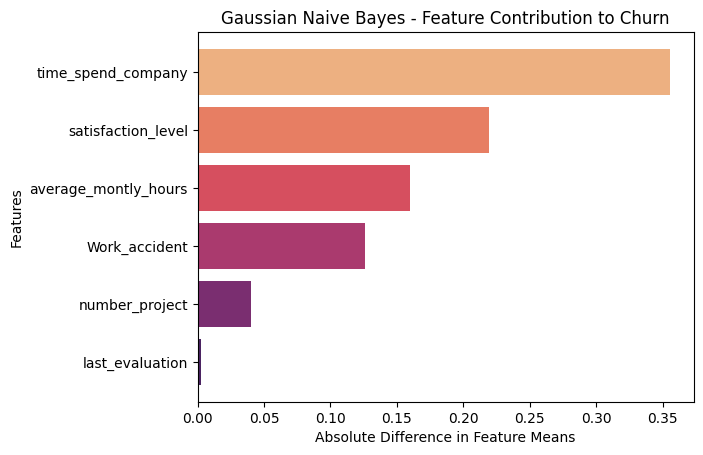

In [132]:

means_df = pd.DataFrame(
    gauss_nb.theta_, 
    columns=X_train_gnb.columns, 
    index=['Stayed', 'Left']
).T

cmap = plt.colormaps['flare_r']
colors = [cmap(i) for i in np.linspace(0, 1, len(means_df))]

means_df['Contribution'] = (means_df['Stayed'] - means_df['Left']).abs()
means_df_sorted = means_df.sort_values(by='Contribution', ascending=True)

plt.barh(means_df_sorted.index, means_df_sorted['Contribution'], color=colors)
plt.xlabel('Absolute Difference in Feature Means')
plt.ylabel('Features')
plt.title('Gaussian Naive Bayes - Feature Contribution to Churn')

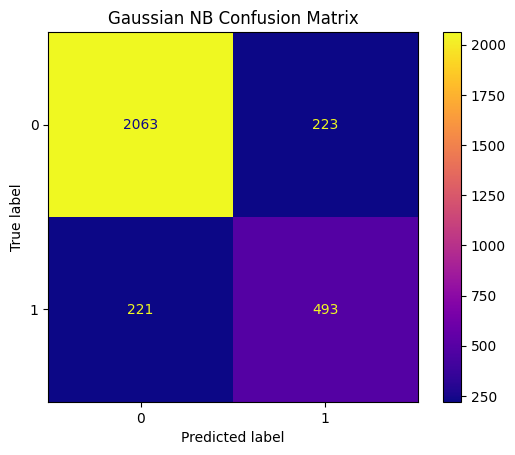

In [76]:
cm = metrics.confusion_matrix(y_val, y_pred_gnb_val, labels=log_reg_cv_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_cv_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Gaussian NB Confusion Matrix')
plt.show()

In [77]:
##A standard confusion matrix is plotted to give a visualization of  the results

In [78]:
##A random forest and xgboost model will now be built to try and improve the approximations. Since these two models are tree based, we do not want to drop columns from the dummies so
##the tree df is used and train test split is used again to split into training, test, and validation data

In [79]:
df_dep_salary_encoded_trees['burn_out'] = (df_dep_salary_encoded_trees['number_project'] > 6).astype(int)
df_dep_salary_encoded_trees.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_IT,Department_RandD,...,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low,salary_medium,burn_out
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [80]:
X_tree = df_dep_salary_encoded_trees.drop(columns=['left'])
y_tree = df_dep_salary_encoded_trees['left']

In [81]:
X_build_tree, X_val_tree, y_build_tree, y_val_tree = train_test_split(X_tree, y_tree, test_size=0.2, stratify=y_tree, random_state=42)
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_build_tree, y_build_tree, test_size=0.25, stratify=y_build_tree, random_state=42)

In [82]:
rf = RandomForestClassifier(random_state=42)

In [83]:
rf_cv_params = {
    'n_estimators':[100, 150],
    'max_depth':[8, 10, 16],
    'min_samples_split':[5, 10],
    'min_samples_leaf': [3, 5, 7],
    'max_features': ['sqrt']
}

In [84]:
scoring_rf = ['accuracy', 'precision', 'recall', 'f1']

In [85]:
rf_cv = GridSearchCV(rf, rf_cv_params, scoring=scoring_rf, refit='f1', n_jobs=-1)

In [86]:
# rf_cv.fit(X_train_tree, y_train_tree)

In [87]:
directory = os.getcwd()
rf_cv_path = os.path.join(directory,'rf_cv_best.pickle')

In [88]:
# with open(rf_cv_path, 'wb') as to_write:
#     pickle.dump(rf_cv, to_write)

In [89]:
with open(rf_cv_path, 'rb') as to_read:
    rf_cv = pickle.load(to_read)

In [90]:
rf_cv.best_params_

{'max_depth': 16,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'min_samples_split': 5,
 'n_estimators': 150}

In [91]:
rf_cv_best = rf_cv.best_estimator_

In [92]:
y_val_tree_pred = rf_cv_best.predict(X_val_tree)

In [93]:
print('Accuracy Score: ', round(accuracy_score(y_val_tree, y_val_tree_pred), 2))
print('Recall Score: ', round(recall_score(y_val_tree, y_val_tree_pred), 2))
print('precision Score: ', round(precision_score(y_val_tree, y_val_tree_pred), 2))

Accuracy Score:  0.98
Recall Score:  0.92
precision Score:  0.99


In [94]:
##This model predicts the data much better. Starting with the hyperparameter tuning, The tree wants to grow deep and create split so it can get its leaves all the way down to 1 sample
##per leaf. When this is the case, we end up with scores in the range of 0.99-1.0 for accuracy, recall, and precision. Since this is very symptomatic of overfitting, a larger tree, made
##available but 1 sample per leaf is removed as an option. Even with this, we end up with accuracy at 0.98, recall at 0.92, and precision at 0.99. This model clearly does a much better
##job with the validation set than the others. The model correctly predicts churning vs staying for 98% of employees (accuracy). The strong recall score of 0.92 indicaters that when
##an employee did leave, we were able to flag it 92% of time. Finally, the 0.99 precision indicates that when we did flag an employee to churn, we were correct with our flag 99% of 
##the time. We knew going in that the random forest would probably be a much better predictor than both NB and logistic regression, and even with decent results from Gauss NB, this is 
##clear proof of that.

C:\Users\matth\AppData\Local\Temp\ipykernel_9268\4091853595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  rf_importances = sns.barplot(


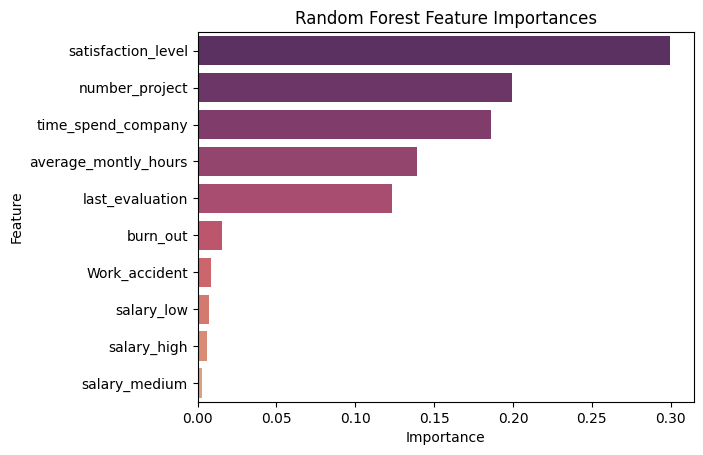

In [129]:
importances = rf_cv_best.feature_importances_
feat_importances = pd.Series(importances, index=X_val_tree.columns).sort_values(ascending=False)
feat_df = feat_importances.reset_index()
feat_df.columns = ['Feature', 'Importance']

rf_importances = sns.barplot(
    feat_df.head(10),
    x='Importance',
    y='Feature',
    palette='flare_r'
)

plt.title('Random Forest Feature Importances')
plt.show()

In [96]:
##The feature importances are extracted and plotted so that we can identify what the most critical features are as identified by the model.

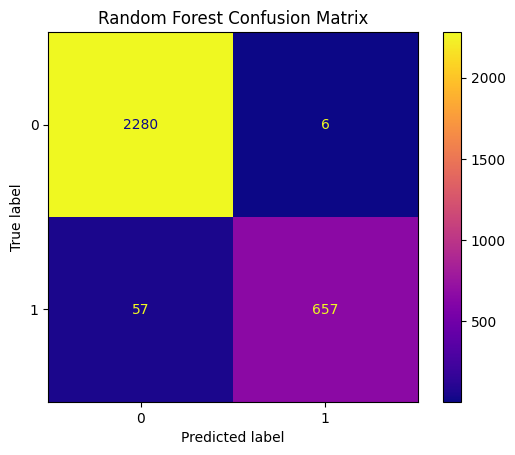

In [97]:
cm = metrics.confusion_matrix(y_val_tree, y_val_tree_pred, labels=rf_cv_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_cv_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Random Forest Confusion Matrix')
plt.show()

In [98]:
##a standard confusion matrix is plotted to graphically represent the results. 

In [99]:
xgb = XGBClassifier(random_state = 42)

In [100]:
xgb_params = {
    'max_depth':[3,5,7],
    'learning_rate':[0.01, 0.1],
    'n_estimators':[100,500]
}

In [104]:
scoring_xgb = ['accuracy', 'precision', 'f1', 'recall']

In [105]:
xgb_cv = GridSearchCV(xgb, param_grid=xgb_params, scoring=scoring_xgb, cv=5, refit='f1', n_jobs=-1)

In [106]:
xgb_cv.fit(X_train_tree, y_train_tree)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [107]:
xgb_cv.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500}

In [108]:
xgb_cv_best = xgb_cv.best_estimator_

In [109]:
y_val_tree_pred_xgb = xgb_cv_best.predict(X_val_tree)

In [110]:
print('Accuracy Score: ', round(accuracy_score(y_val_tree, y_val_tree_pred_xgb), 2))
print('Recall Score: ', round(recall_score(y_val_tree, y_val_tree_pred_xgb), 2))
print('precision Score: ', round(precision_score(y_val_tree, y_val_tree_pred_xgb), 2))

Accuracy Score:  0.99
Recall Score:  0.97
precision Score:  0.98


C:\Users\matth\AppData\Local\Temp\ipykernel_9268\1787564719.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  xgb_importances = sns.barplot(


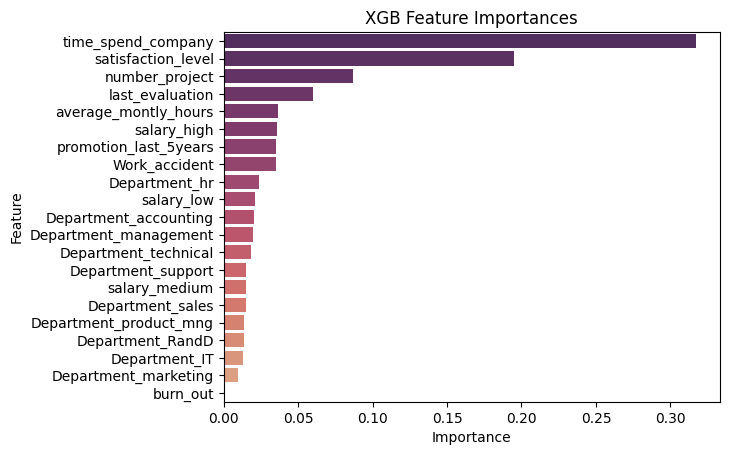

In [128]:
xgb_importances = xgb_cv_best.feature_importances_
xgb_feat_importances = pd.Series(xgb_importances, index=X_val_tree.columns).sort_values(ascending=False)
feat_xgb_df = xgb_feat_importances.reset_index()
feat_xgb_df.columns = ['Feature', 'Importance']

xgb_importances = sns.barplot(
    feat_xgb_df,
    x='Importance',
    y='Feature',
    palette='flare_r'
)

plt.title('XGB Feature Importances')
plt.show()

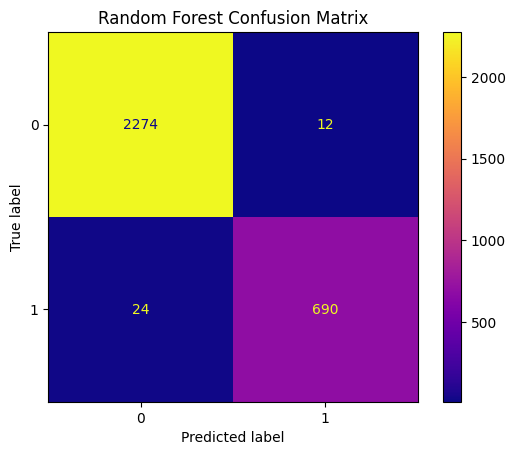

In [133]:
cm = metrics.confusion_matrix(y_val_tree, y_val_tree_pred_xgb, labels=rf_cv_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_cv_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
##For all intents and purposes the xgb boost model confirms what was predicted by random forest classifier, with a bit of increased recall score. Ideally, we would select a model that 
##had a better recall score, however, in order to calculate this model the tradeoff is steep: the gradient boost is building upwards of 500 trees, at a depth of 7, and a learning 
##rate of 0.1. 
##
##This means that the model is incredibly aggressive, and uses a lot of computational resources to return a prediction. In addition, the way that the model arrives at this calculation, 
##by computing error estimates and performing rapid corrections, leaves some level of ambiguity in the feature importances. 
##
##Because of this, it is a much better idea for Salifort Motors to take the simpler, more thoughtful, robust and well constructed model, the random forest. This will give a strong 
##baseline for determining which factors are causing workers to churn.